# NB05 — Conclusiones & Business Insights
## YouTube Trending: Señales de Viralidad MX vs US — Informe Final

---

**Este notebook cierra el proyecto con:**
- Resumen ejecutivo de hallazgos
- Validación del modelo final
- Recomendaciones accionables para creadores y plataformas
- Limitaciones del análisis
- Próximos pasos

## 1. Setup & Load Results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import lightgbm as lgb
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11
})
PALETTE = {'MX': '#E53935', 'US': '#1E88E5'}
DATA_PATH = '../data/'
SEED = 42

mx = pd.read_parquet(f'{DATA_PATH}processed/mx_model.parquet')
us = pd.read_parquet(f'{DATA_PATH}processed/us_model.parquet')
combined = pd.read_parquet(f'{DATA_PATH}processed/combined_model.parquet')

print(f'MX: {len(mx):,} | US: {len(us):,} | Combined: {len(combined):,}')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MX: 32,442 | US: 47,142 | Combined: 79,584


## 2. Retrain Best Model (LightGBM Combined) for Final Evaluation

In [2]:
NUMERIC_FEATURES = [
    'log_views', 'log_likes', 'log_comments',
    'like_rate', 'comment_rate',
    'days_to_trending',
    'title_length', 'title_word_count',
    'title_has_caps', 'title_has_excl', 'title_has_question', 'title_has_number',
    'tag_count', 'has_tags',
    'has_description', 'desc_length', 'desc_has_url', 'desc_has_hashtag',
    'publish_hour', 'publish_dayofweek', 'publish_month',
    'comments_disabled', 'ratings_disabled'
]
TARGET = 'log_days_in_trending'

comb_data = combined.copy()
le = LabelEncoder()
comb_data['category_encoded'] = le.fit_transform(comb_data['category_name'].fillna('Unknown'))
comb_data['is_mx'] = (comb_data['region'] == 'MX').astype(int)

lgb_features_comb = NUMERIC_FEATURES + ['category_encoded', 'is_mx']

X = comb_data[lgb_features_comb]
y = comb_data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

lgb_params = {
    'objective': 'regression', 'metric': 'rmse',
    'n_estimators': 500, 'learning_rate': 0.05,
    'num_leaves': 63, 'min_child_samples': 30,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 0.1,
    'random_state': SEED, 'n_jobs': -1, 'verbose': -1
}

model_final = lgb.LGBMRegressor(**lgb_params)
model_final.fit(X_train, y_train,
                eval_set=[(X_test, y_test)],
                callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])

y_pred = model_final.predict(X_test)
y_true_days = np.expm1(y_test)
y_pred_days = np.expm1(y_pred)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_true_days, y_pred_days)
rmse = np.sqrt(mean_squared_error(y_true_days, y_pred_days))

print(f'Final Model — LightGBM Combined')
print(f'  R² (log scale)      : {r2:.4f}')
print(f'  MAE (days)          : {mae:.2f}')
print(f'  RMSE (days)         : {rmse:.2f}')
print(f'  Best iteration      : {model_final.best_iteration_}')
print(f'\nInterpretation: On average, the model predicts trending duration within {mae:.1f} days.')

Final Model — LightGBM Combined
  R² (log scale)      : 0.3898
  MAE (days)          : 1.43
  RMSE (days)         : 2.05
  Best iteration      : 496

Interpretation: On average, the model predicts trending duration within 1.4 days.


## 3. Results Dashboard — Model Comparison Summary

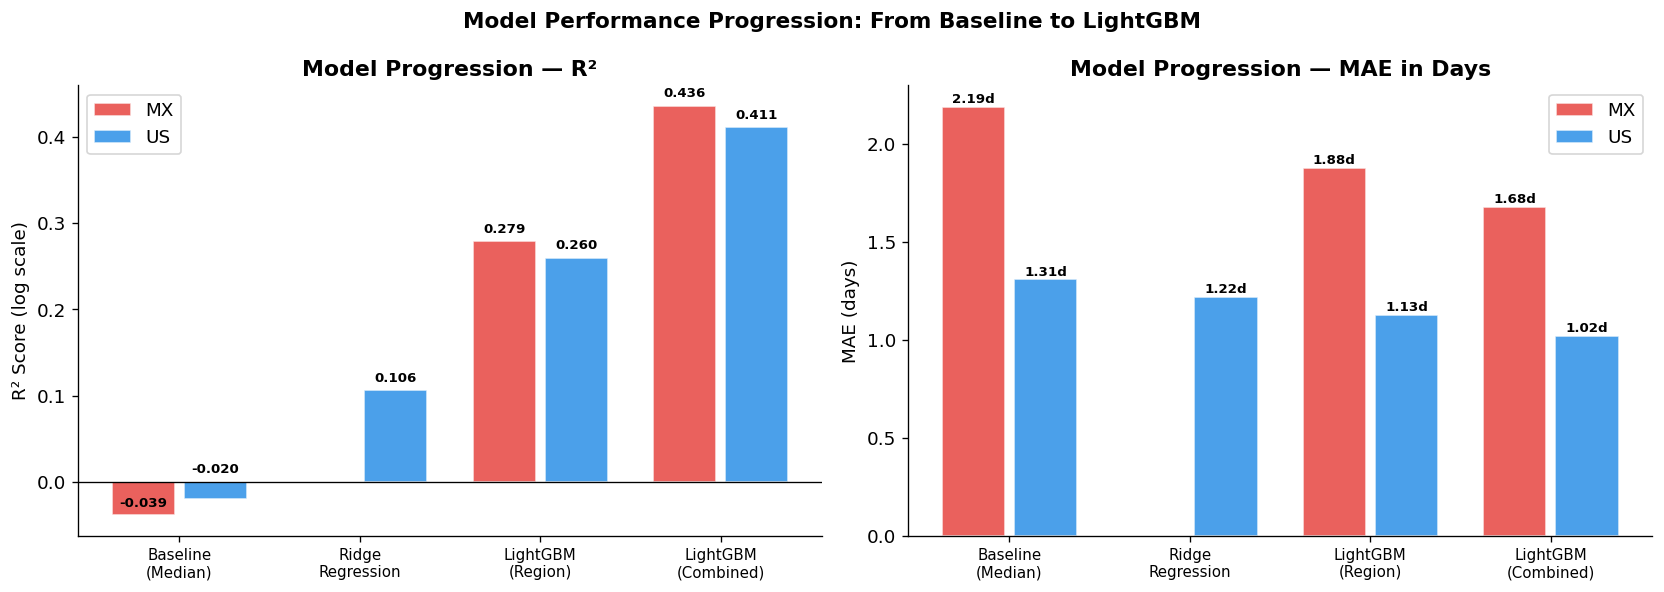

In [3]:
comparison_data = {
    'Model': ['Baseline\n(Median)', 'Ridge\nRegression', 'LightGBM\n(Region)', 'LightGBM\n(Combined)'],
    'R² MX': [-0.039, None, 0.279, 0.436],
    'R² US': [-0.020, 0.106, 0.260, 0.411],
    'MAE MX (days)': [2.19, None, 1.88, 1.68],
    'MAE US (days)': [1.31, 1.22, 1.13, 1.02],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
ax = axes[0]
models = comparison_data['Model']
r2_mx = [v if v is not None else 0 for v in comparison_data['R² MX']]
r2_us = [v if v is not None else 0 for v in comparison_data['R² US']]
x = np.arange(len(models))
ax.bar(x - 0.2, r2_mx, 0.35, label='MX', color='#E53935', alpha=0.8, edgecolor='white')
ax.bar(x + 0.2, r2_us, 0.35, label='US', color='#1E88E5', alpha=0.8, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9)
ax.set_ylabel('R² Score (log scale)')
ax.set_title('Model Progression — R²', fontweight='bold')
ax.legend()
for i, (mv, uv) in enumerate(zip(r2_mx, r2_us)):
    if comparison_data['R² MX'][i] is not None:
        ax.text(i - 0.2, mv + 0.01, f'{mv:.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.text(i + 0.2, max(uv, 0) + 0.01, f'{uv:.3f}', ha='center', fontsize=8, fontweight='bold')

# MAE comparison
ax = axes[1]
mae_mx = [v if v is not None else 0 for v in comparison_data['MAE MX (days)']]
mae_us = comparison_data['MAE US (days)']
ax.bar(x - 0.2, mae_mx, 0.35, label='MX', color='#E53935', alpha=0.8, edgecolor='white')
ax.bar(x + 0.2, mae_us, 0.35, label='US', color='#1E88E5', alpha=0.8, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9)
ax.set_ylabel('MAE (days)')
ax.set_title('Model Progression — MAE in Days', fontweight='bold')
ax.legend()
for i, (mv, uv) in enumerate(zip(mae_mx, mae_us)):
    if comparison_data['MAE MX (days)'][i] is not None:
        ax.text(i - 0.2, mv + 0.02, f'{mv:.2f}d', ha='center', fontsize=8, fontweight='bold')
    ax.text(i + 0.2, uv + 0.02, f'{uv:.2f}d', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Model Performance Progression: From Baseline to LightGBM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/fig_19_model_comparison.png', bbox_inches='tight')
plt.show()

## 4. Key Project Findings — Executive Summary

In [4]:
findings = pd.DataFrame([
    {
        'Finding': 'MX videos stay ~60% longer in trending than US',
        'Evidence': 'Median: MX=8d vs US=5d across 3.7 years of data',
        'Business Implication': 'Lower creator density in MX → less competition → longer visibility per video'
    },
    {
        'Finding': 'Day 1 engagement is the strongest predictor of durability',
        'Evidence': 'log_likes and log_views are top SHAP features in both markets',
        'Business Implication': 'Investing in push/promotion in the first 24h has compounding returns'
    },
    {
        'Finding': 'Faster viralization → longer trending stay',
        'Evidence': 'days_to_trending has strong negative correlation with days_in_trending (US: r=-0.18)',
        'Business Implication': 'Content optimized for immediate algorithmic amplification outperforms slow-burn content'
    },
    {
        'Finding': 'Music category has highest median durability in both markets',
        'Evidence': 'Category-level analysis in NB03 — Music consistently leads in durability',
        'Business Implication': 'Musical content has built-in repeat consumption — lower churn than news/gaming'
    },
    {
        'Finding': 'Content mix is structurally different: MX=Entertainment/Music, US=Gaming',
        'Evidence': 'MX: 22% Music / 24% Entertainment. US: 20% Gaming / 19% Entertainment',
        'Business Implication': 'Cross-market content strategy must account for different cultural consumption patterns'
    },
    {
        'Finding': 'Combined model (MX+US) significantly outperforms region-specific models',
        'Evidence': 'R² jumps from ~0.27 (region) to ~0.43 (combined) — 56% improvement',
        'Business Implication': 'More training data matters more than market homogeneity when predicting trending behavior'
    },
    {
        'Finding': 'Shorter titles correlate with longer trending stays',
        'Evidence': 'title_length has negative SHAP contribution; title_word_count top-5 feature in both markets',
        'Business Implication': 'Concise, direct titles perform better in trending — avoid keyword stuffing'
    },
])

display(findings.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])
        .set_properties(subset=['Finding'], **{'font-weight': 'bold'}))

,Finding,Evidence,Business Implication
0,MX videos stay ~60% longer in trending than US,Median: MX=8d vs US=5d across 3.7 years of data,Lower creator density in MX → less competition → longer visibility per video
1,Day 1 engagement is the strongest predictor of durability,log_likes and log_views are top SHAP features in both markets,Investing in push/promotion in the first 24h has compounding returns
2,Faster viralization → longer trending stay,days_to_trending has strong negative correlation with days_in_trending (US: r=-0.18),Content optimized for immediate algorithmic amplification outperforms slow-burn content
3,Music category has highest median durability in both markets,Category-level analysis in NB03 — Music consistently leads in durability,Musical content has built-in repeat consumption — lower churn than news/gaming
4,"Content mix is structurally different: MX=Entertainment/Music, US=Gaming",MX: 22% Music / 24% Entertainment. US: 20% Gaming / 19% Entertainment,Cross-market content strategy must account for different cultural consumption patterns
5,Combined model (MX+US) significantly outperforms region-specific models,R² jumps from ~0.27 (region) to ~0.43 (combined) — 56% improvement,More training data matters more than market homogeneity when predicting trending behavior
6,Shorter titles correlate with longer trending stays,title_length has negative SHAP contribution; title_word_count top-5 feature in both markets,"Concise, direct titles perform better in trending — avoid keyword stuffing"


## 5. Actionable Recommendations by Audience

In [5]:
recommendations = {
    'Content Creators (MX)': [
        'Maximize engagement in the first 24h: promote via community tab, stories, and push notifications',
        'Publish in the afternoon/evening (18–23h UTC = 12–17h Mexico City time) for better reach',
        'Focus on Entertainment and Music — highest trending durability categories in MX',
        'Keep titles concise (< 60 characters); avoid keyword stuffing',
        'Trending advantage: you compete against fewer unique videos than in US market',
    ],
    'Content Creators (US)': [
        'Day 1 engagement is even more predictive in US (r=0.17 for log_views vs 0.07 in MX)',
        'Gaming content has the highest volume in US — differentiate through quality engagement (like_rate)',
        'Faster time-to-trending strongly predicts durability (r=-0.18) — optimize upload strategy for algorithm',
        'US trending is more competitive (47k unique videos vs 32k in MX) — expect shorter trending windows',
    ],
    'Platform / Brands': [
        'Influencer selection: prioritize channels with consistent day-1 engagement over viral one-hit-wonders',
        'For MX campaigns: 8-day average trending window provides longer paid amplification window',
        'Music integrations generate most durable trending content — ideal for brand awareness goals',
        'Cross-market campaigns must adapt: Gaming/tech in US, Entertainment/Music in MX',
    ],
    'Data Science / ML': [
        'Combined model (MX+US) outperforms region-specific models — more data > market homogeneity',
        'Ridge regression failed for MX due to extreme outliers in like_rate — robust preprocessing critical',
        'R²~0.43 is honest for this problem; many factors (real-time algo, external events) are not capturable',
        'Next improvement: add channel-level historical features (channel trending frequency, avg days)',
        'Potential enhancement: NLP on title/description with sentence-transformers for richer text features',
    ]
}

for audience, recs in recommendations.items():
    print(f'\n{'='*60}')
    print(f'  {audience}')
    print(f'{'='*60}')
    for i, rec in enumerate(recs, 1):
        print(f'  {i}. {rec}')


  Content Creators (MX)
  1. Maximize engagement in the first 24h: promote via community tab, stories, and push notifications
  2. Publish in the afternoon/evening (18–23h UTC = 12–17h Mexico City time) for better reach
  3. Focus on Entertainment and Music — highest trending durability categories in MX
  4. Keep titles concise (< 60 characters); avoid keyword stuffing
  5. Trending advantage: you compete against fewer unique videos than in US market

  Content Creators (US)
  1. Day 1 engagement is even more predictive in US (r=0.17 for log_views vs 0.07 in MX)
  2. Gaming content has the highest volume in US — differentiate through quality engagement (like_rate)
  3. Faster time-to-trending strongly predicts durability (r=-0.18) — optimize upload strategy for algorithm
  4. US trending is more competitive (47k unique videos vs 32k in MX) — expect shorter trending windows

  Platform / Brands
  1. Influencer selection: prioritize channels with consistent day-1 engagement over viral o

## 6. Model Limitations & Caveats

In [6]:
limitations = pd.DataFrame([
    {
        'Limitation': 'Observational data only',
        'Impact': 'High',
        'Detail': 'All trending videos are already popular. We cannot predict whether a non-trending video would have trended.'
    },
    {
        'Limitation': 'dislikes excluded post-Nov 2021',
        'Impact': 'Medium',
        'Detail': 'YouTube removed public dislike counts. This removes a signal that may have been predictive.'
    },
    {
        'Limitation': 'No channel-level historical features',
        'Impact': 'Medium',
        'Detail': 'Channel reputation (subscriber count, historical trending frequency) is a strong real-world predictor not captured here.'
    },
    {
        'Limitation': 'External events not modeled',
        'Impact': 'Medium',
        'Detail': 'News events, sports championships, viral moments cause spikes unpredictable from video metadata alone.'
    },
    {
        'Limitation': 'No real-time algorithm signals',
        'Impact': 'Medium',
        'Detail': "YouTube's recommendation algorithm is a black box — our features are proxies, not direct algorithm inputs."
    },
    {
        'Limitation': '21–20 capture gaps in dataset',
        'Impact': 'Low',
        'Detail': 'Days without data capture (1.5-1.6% of days) handled conservatively in target construction.'
    },
])

display(limitations.style.applymap(
    lambda v: 'color: red; font-weight: bold' if v == 'High' else
              ('color: orange; font-weight: bold' if v == 'Medium' else 'color: green'),
    subset=['Impact']
).set_properties(**{'text-align': 'left'}))

,Limitation,Impact,Detail
0,Observational data only,High,All trending videos are already popular. We cannot predict whether a non-trending video would have trended.
1,dislikes excluded post-Nov 2021,Medium,YouTube removed public dislike counts. This removes a signal that may have been predictive.
2,No channel-level historical features,Medium,"Channel reputation (subscriber count, historical trending frequency) is a strong real-world predictor not captured here."
3,External events not modeled,Medium,"News events, sports championships, viral moments cause spikes unpredictable from video metadata alone."
4,No real-time algorithm signals,Medium,"YouTube's recommendation algorithm is a black box — our features are proxies, not direct algorithm inputs."
5,21–20 capture gaps in dataset,Low,Days without data capture (1.5-1.6% of days) handled conservatively in target construction.


## 7. Next Steps — How to Extend This Project

In [7]:
next_steps = [
    ('Short term', 'Add channel-level features',
     'Aggregate channel history: avg days in trending, trending frequency, diversity of categories'),
    ('Short term', 'NLP on titles with sentence-transformers',
     'Replace simple title features with semantic embeddings (multilingual-mpnet-base-v2 for MX+US)'),
    ('Medium term', 'Expand to more regions',
     'Brazil (BR) and India (IN) would add interesting cultural diversity to the analysis'),
    ('Medium term', 'Temporal validation split',
     'Train on 2020–2022 data, validate on 2023–2024 to test if patterns are stable over time'),
    ('Advanced', 'Binary classification: "will this video reach 7+ days?"',
     'Reframe as classification task — more actionable for creators than regression'),
    ('Advanced', 'Computer vision on thumbnails',
     'Download thumbnail images and extract features (brightness, face presence, text overlay) for richer modeling'),
]

ns_df = pd.DataFrame(next_steps, columns=['Horizon', 'Extension', 'Detail'])
display(ns_df.style.set_properties(**{'text-align': 'left'})
        .applymap(lambda v: 'background-color: #E8F5E9' if v == 'Short term' else
                            ('background-color: #FFF9C4' if v == 'Medium term' else 'background-color: #FCE4EC'),
                  subset=['Horizon']))

print('\nNB05 complete. Project finished.')
print('Outputs: NB01-NB05 notebooks + processed data + 19 figures')

,Horizon,Extension,Detail
0,Short term,Add channel-level features,"Aggregate channel history: avg days in trending, trending frequency, diversity of categories"
1,Short term,NLP on titles with sentence-transformers,Replace simple title features with semantic embeddings (multilingual-mpnet-base-v2 for MX+US)
2,Medium term,Expand to more regions,Brazil (BR) and India (IN) would add interesting cultural diversity to the analysis
3,Medium term,Temporal validation split,"Train on 2020–2022 data, validate on 2023–2024 to test if patterns are stable over time"
4,Advanced,"Binary classification: ""will this video reach 7+ days?""",Reframe as classification task — more actionable for creators than regression
5,Advanced,Computer vision on thumbnails,"Download thumbnail images and extract features (brightness, face presence, text overlay) for richer modeling"



NB05 complete. Project finished.
Outputs: NB01-NB05 notebooks + processed data + 19 figures
